# Vocabulary Characteristics Across Albums

In [33]:
from turtledemo.chaos import plot

import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import plotly.express as px
import ast
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

from pygments.lexer import words

from lana_nlp.analysis.lyrics_analyzer import LyricsAnalyzer
from lana_nlp.analysis.vocabulary import VocabularyAnalyzer
from lana_nlp.analysis.readability import ReadabilityAnalyzer
from lana_nlp.analysis.sentiment import SentimentAnalyzer

In [2]:
df = pd.read_csv("../data/processed/lyrics.csv")

# make sure nlp_cleaned_lyrics is a list of tokens
df["nlp_cleaned_lyrics"] = (
    df["nlp_cleaned_lyrics"]
    .apply(ast.literal_eval)
)

In [3]:
analyzer = LyricsAnalyzer(
    df,
    basic_text_column="basic_cleaned_lyrics",
    nlp_text_column="nlp_cleaned_lyrics",
)

df = analyzer.analyze()

In [4]:
df.head()

,Unnamed: 0,artist,album,song,year,lyrics,basic_cleaned_lyrics,nlp_cleaned_lyrics,word_count,unique_words,syllable_count,line_count,reading_minutes
0,0,Lana Del Rey,Sirens,Drive By,2006,There was a drive-by Sunday night\nMost of us ...,there was a driveby sunday night\nmost of us w...,"[driveby, sunday, night, u, bed, right, turned...",248,97,295,37,1.240
1,1,Lana Del Rey,Sirens,River Road,2006,"Another day is over, another day is done\nAnd ...",another day is over another day is done\nand n...,"[another, day, another, day, done, im, gettin,...",166,64,211,30,0.830
2,2,Lana Del Rey,Sirens,A Star for Nick,2006,"Well, you know it and I know it, I'm gonna be ...",well you know it and i know it im gonna be a s...,"[well, know, know, im, gon, na, star, wont, wo...",84,44,98,15,0.420
3,3,Lana Del Rey,Sirens,My Momma,2006,My momma wouldn't say you were a nice guy\nBut...,my momma wouldnt say you were a nice guy\nbut ...,"[momma, wouldnt, say, nice, guy, youre, 40, jo...",277,114,322,37,1.385
4,4,Lana Del Rey,Sirens,Bad Disease,2006,"Well, there's somethin' about watchin' a crime...",well theres somethin about watchin a crime\nth...,"[well, there, somethin, watchin, crime, make, ...",227,109,268,40,1.135


## Vocabulary Size

How large is Lana's vocabulary?

In [5]:
vocabulary_by_album = (
    df.groupby(["album", "year"])["nlp_cleaned_lyrics"]
    .apply(lambda songs: len(set(word for song in songs for word in song)))
    .reset_index(name="vocabulary_size")
)

vocabulary_by_album

,album,year,vocabulary_size
0,Blue Banisters,2021,679
1,Born To Die,2012,812
2,Chemtrails Over the Country Club,2021,515
3,Did You Know That There's a Tunnel Under Ocean...,2023,910
4,Honeymoon,2015,541
5,"Lana Del Ray, A.K.A. Lizzy Grant",2010,404
6,Lust for Life,2016,794
7,Norman Fucking Rockwell!,2019,688
8,Paradise,2012,428
9,Sirens,2006,520


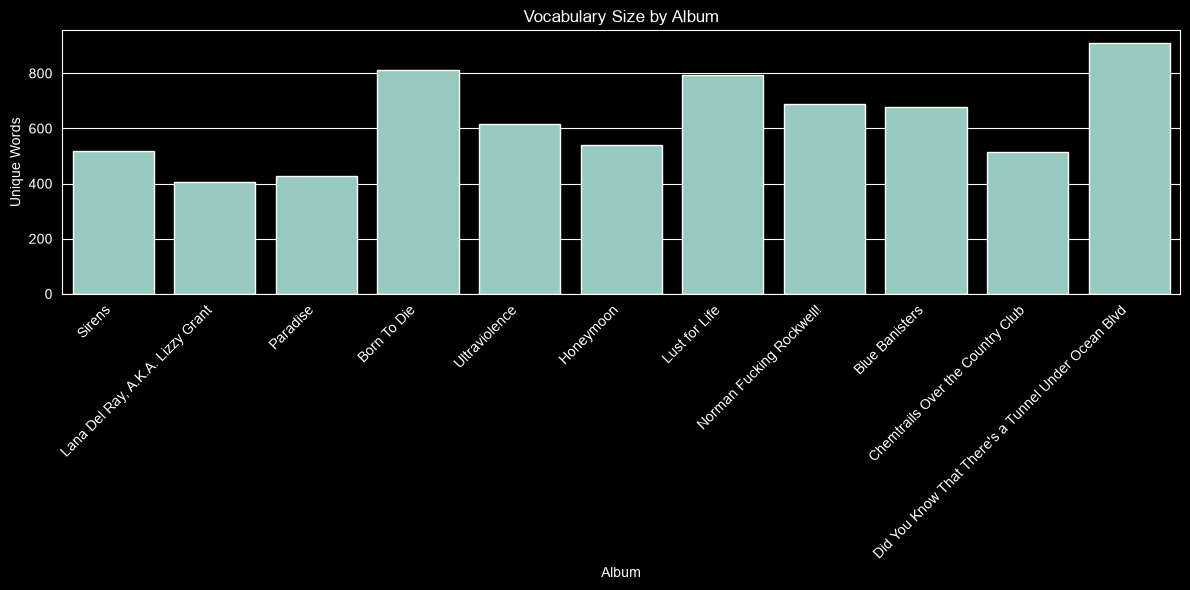

In [6]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=vocabulary_by_album.sort_values("year"),
    x="album",
    y="vocabulary_size"
)

plt.xticks(rotation=45, ha="right")
plt.xlabel("Album")
plt.ylabel("Unique Words")
plt.title("Vocabulary Size by Album")
plt.tight_layout()
plt.show()

## Repeated Words

How much does Lana repeat herself?

In [8]:
vocabulary_stats = (
    df.groupby(["album", "year"])["nlp_cleaned_lyrics"]
    .apply(
        lambda songs: [
            word
            for song in songs
            for word in song
        ]
    )
    .reset_index(name="all_words")
)

# Total number of word occurrences
vocabulary_stats["total_words"] = (
    vocabulary_stats["all_words"]
    .apply(len)
)

# Number of unique words
vocabulary_stats["vocabulary_size"] = (
    vocabulary_stats["all_words"]
    .apply(lambda words: len(set(words)))
)

# Repitition Rate
vocabulary_stats["repetition_rate"] = (
    1
    - vocabulary_stats["vocabulary_size"]
    / vocabulary_stats["total_words"]
)

vocabulary_stats[
    [
        "album",
        "year",
        "total_words",
        "vocabulary_size",
        "repetition_rate"
    ]
].sort_values("year")

,album,year,total_words,vocabulary_size,repetition_rate
9,Sirens,2006,1568,520,0.668367
5,"Lana Del Ray, A.K.A. Lizzy Grant",2010,1728,404,0.766204
8,Paradise,2012,1451,428,0.705031
1,Born To Die,2012,3312,812,0.754831
10,Ultraviolence,2014,2490,615,0.753012
4,Honeymoon,2015,1999,541,0.729365
6,Lust for Life,2016,2990,794,0.734448
7,Norman Fucking Rockwell!,2019,2397,688,0.712975
0,Blue Banisters,2021,2222,679,0.694419
2,Chemtrails Over the Country Club,2021,1708,515,0.698478


In [12]:
# See the repeated words
def get_word_frequencies(words):
    return Counter(words)

In [14]:
album_word_counts = {}

for _, row in vocabulary_stats.iterrows():
    album_word_counts[row["album"]] = Counter(row["all_words"])

album_word_counts["Born To Die"].most_common(20)

[('like', 96),
 ('im', 76),
 ('love', 74),
 ('baby', 73),
 ('youre', 50),
 ('dont', 48),
 ('know', 38),
 ('oh', 36),
 ('get', 31),
 ('na', 31),
 ('say', 30),
 ('think', 30),
 ('cause', 27),
 ('tell', 26),
 ('time', 26),
 ('girl', 25),
 ('want', 25),
 ('boy', 25),
 ('summertime', 25),
 ('hey', 24)]

## Most Frequent Words

What words does she use the most?

In [15]:
# Get the top words
top_words_by_album = {}

for _, row in vocabulary_stats.iterrows():
    top_words_by_album[row["album"]] = (
        Counter(row["all_words"]).most_common(15)
    )

In [16]:
print(top_words_by_album["Born To Die"])

[('like', 96), ('im', 76), ('love', 74), ('baby', 73), ('youre', 50), ('dont', 48), ('know', 38), ('oh', 36), ('get', 31), ('na', 31), ('say', 30), ('think', 30), ('cause', 27), ('tell', 26), ('time', 26)]


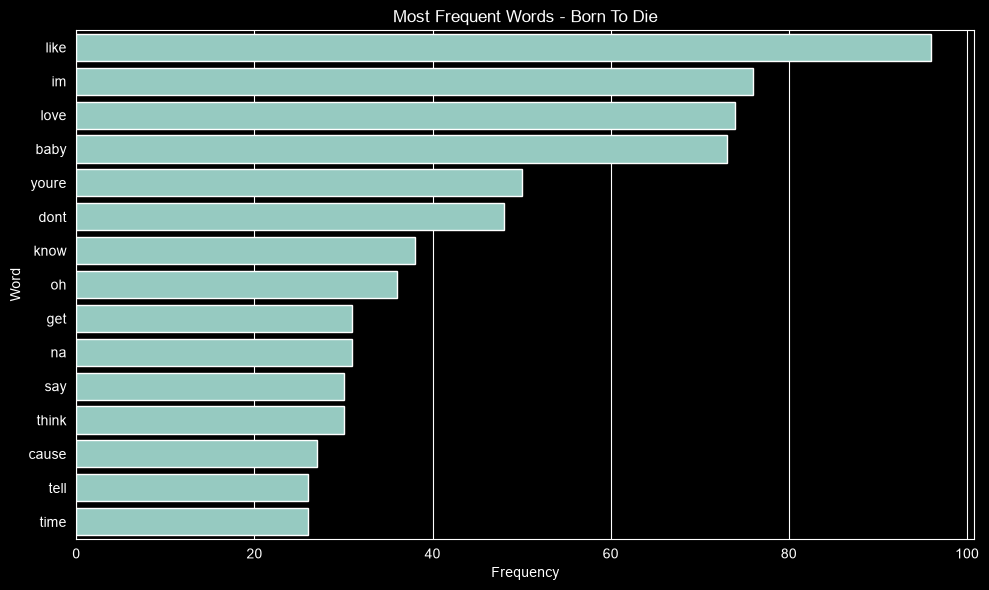

In [17]:
album = "Born To Die"

word_counts = (
    Counter(vocabulary_stats.loc[
        vocabulary_stats["album"] == album,
        "all_words"
        ].iloc[0]
    )
)

top_words = word_counts.most_common(15)

words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(10, 6))

sns.barplot(
    x=counts,
    y=words
)

plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title(f"Most Frequent Words - {album}")
plt.tight_layout()
plt.show()

In [18]:
# Dataframe with top words from every album
top_words_df = []

for _, row in vocabulary_stats.iterrows():

    counts = Counter(row["all_words"])

    for word, count in counts.most_common(15):
        top_words_df.append({
            "album": row["album"],
            "year": row["year"],
            "word": word,
            "frequency": count
        })

top_words_df = pd.DataFrame(top_words_df)

top_words_df

,album,year,word,frequency
0,Blue Banisters,2021,like,58
1,Blue Banisters,2021,dont,47
2,Blue Banisters,2021,baby,40
3,Blue Banisters,2021,know,29
4,Blue Banisters,2021,ooh,28
...,...,...,...,...
160,Ultraviolence,2014,pretty,28
161,Ultraviolence,2014,sad,28
162,Ultraviolence,2014,na,26
163,Ultraviolence,2014,gun,24


In [31]:
top_words_df[
    top_words_df["album"] == "Did You Know That There's a Tunnel Under Ocean Blvd"
]

,album,year,word,frequency
45,Did You Know That There's a Tunnel Under Ocean...,2023,im,90
46,Did You Know That There's a Tunnel Under Ocean...,2023,know,71
47,Did You Know That There's a Tunnel Under Ocean...,2023,love,62
48,Did You Know That There's a Tunnel Under Ocean...,2023,like,55
49,Did You Know That There's a Tunnel Under Ocean...,2023,na,52
50,Did You Know That There's a Tunnel Under Ocean...,2023,dont,49
51,Did You Know That There's a Tunnel Under Ocean...,2023,get,47
52,Did You Know That There's a Tunnel Under Ocean...,2023,youre,43
53,Did You Know That There's a Tunnel Under Ocean...,2023,jimmy,37
54,Did You Know That There's a Tunnel Under Ocean...,2023,say,30


## What Words Make Each Album Lyrically Distinctive?

In [32]:
album_documents = (
    df.groupby(["album", "year"])["nlp_cleaned_lyrics"]
    .apply(lambda songs: " ".join(
        word
        for song in songs
        for word in song
    ))
    .reset_index(name="document")
)

album_documents

,album,year,document
0,Blue Banisters,2021,guess could call text book lookin father wante...
1,Born To Die,2012,got louder got foot dont fail take finish line...
2,Chemtrails Over the Country Club,2021,sun stare dont care head hand thinking simpler...
3,Did You Know That There's a Tunnel Under Ocean...,2023,one two ready im gon na take mind ah mine say ...
4,Honeymoon,2015,know fashionable love dont go cause truly ther...
5,"Lana Del Ray, A.K.A. Lizzy Grant",2010,bound stair im shower know goin leave know goi...
6,Lust for Life,2016,look kid vintage music coming satellite cruisi...
7,Norman Fucking Rockwell!,2019,goddamn manchild fucked good almost said love ...
8,Paradise,2012,oohoohoohooh oohoohooh oohoohoohooh oohoohooh ...
9,Sirens,2006,driveby sunday night u bed right turned light ...


In [34]:
vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(
    album_documents["document"]
)

feature_names = vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=album_documents["album"],
    columns=feature_names
)

tfidf_df

,11,13,16,17,18th,205,24,247,2am,300,...,york,youd,youll,young,youre,yourе,youth,youve,yеah,zoom
album,,,,,,,,,,,,,,,,,,,,,
Blue Banisters,0.014023,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.014023,...,0.000000,0.017010,0.012936,0.000000,0.135622,0.000000,0.000000,0.012936,0.000000,0.014023
Born To Die,0.000000,0.000000,0.018741,0.00937,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.056654,0.000000,0.043220,0.000000,0.167822,0.000000,0.000000,0.000000,0.000000,0.000000
Chemtrails Over the Country Club,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.029584,0.037499,0.007500,0.052419,0.000000,0.000000,0.000000,0.000000,0.000000
Did You Know That There's a Tunnel Under Ocean Blvd,0.000000,0.000000,0.000000,0.00000,0.008779,0.008779,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.044543,0.020247,0.135220,0.008779,0.000000,0.016197,0.008779,0.000000
Honeymoon,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.085092,0.000000,0.000000,0.000000,...,0.000000,0.008601,0.013083,0.006541,0.172718,0.000000,0.000000,0.013083,0.000000,0.000000
"Lana Del Ray, A.K.A. Lizzy Grant",0.000000,0.009769,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.022529,0.000000,0.017496,0.000000,0.000000,0.009012,0.000000,0.000000
Lust for Life,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.046125,0.000000,0.040090,0.089510,0.000000,0.018574,0.030068,0.000000,0.000000
Norman Fucking Rockwell!,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.026777,0.013388,0.000000,...,0.017988,0.000000,0.037052,0.006175,0.105505,0.000000,0.000000,0.006175,0.000000,0.000000
Paradise,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.034098,0.026480,0.000000,0.000000,0.006820,0.000000,0.000000


In [38]:
tfidf_top_words_df = []

for album in tfidf_df.index:

    top_words = (
        tfidf_df.loc[album]
        .sort_values(ascending=False)
        .head(15)
    )

    for word, score in top_words.items():
        tfidf_top_words_df.append({
            "album": album,
            "word": word,
            "tfidf": score
        })

tfidf_top_words_df = pd.DataFrame(tfidf_top_words_df)

tfidf_top_words_df

,album,word,tfidf
0,Blue Banisters,like,0.291337
1,Blue Banisters,dont,0.236083
2,Blue Banisters,burn,0.226094
3,Blue Banisters,baby,0.200922
4,Blue Banisters,ooh,0.152883
...,...,...,...
160,Ultraviolence,love,0.163386
161,Ultraviolence,dont,0.159586
162,Ultraviolence,got,0.159586
163,Ultraviolence,ultraviolence,0.159116


In [56]:
tfidf_top_words_df[
    tfidf_top_words_df["album"] == "Did You Know That There's a Tunnel Under Ocean Blvd"
]

,album,word,tfidf
45,Did You Know That There's a Tunnel Under Ocean...,jimmy,0.324828
46,Did You Know That There's a Tunnel Under Ocean...,im,0.283019
47,Did You Know That There's a Tunnel Under Ocean...,know,0.223271
48,Did You Know That There's a Tunnel Under Ocean...,love,0.194969
49,Did You Know That There's a Tunnel Under Ocean...,necklace,0.175583
50,Did You Know That There's a Tunnel Under Ocean...,like,0.172956
51,Did You Know That There's a Tunnel Under Ocean...,na,0.163522
52,Did You Know That There's a Tunnel Under Ocean...,ha,0.157586
53,Did You Know That There's a Tunnel Under Ocean...,dont,0.154088
54,Did You Know That There's a Tunnel Under Ocean...,candy,0.150082


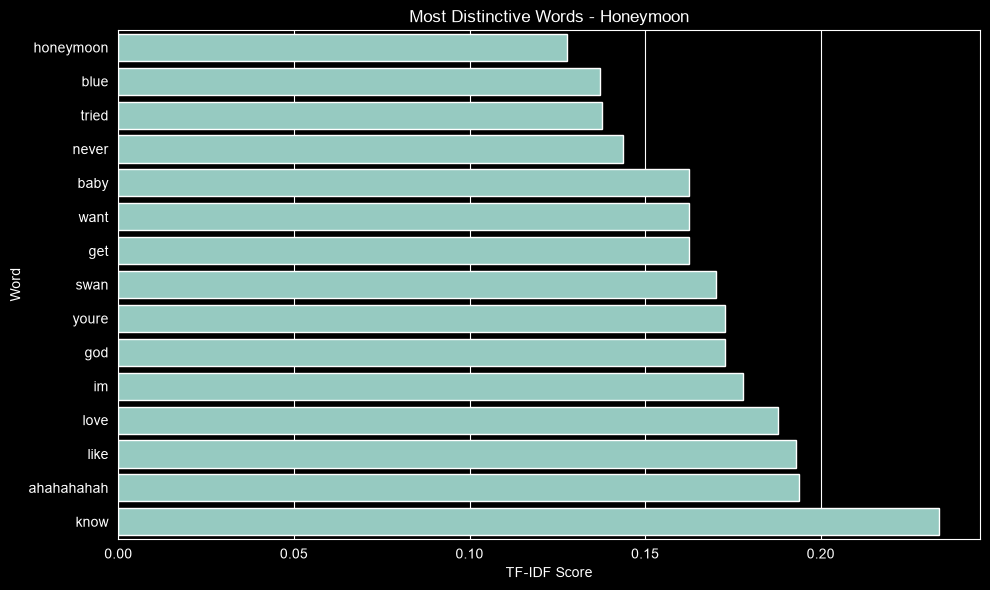

In [42]:
album = "Honeymoon"

plot_data = (
    tfidf_top_words_df[
        tfidf_top_words_df["album"] == album
    ]
    .sort_values("tfidf")
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="tfidf",
    y="word"
)

plt.xlabel("TF-IDF Score")
plt.ylabel("Word")
plt.title(f"Most Distinctive Words - {album}")
plt.tight_layout()
plt.show()

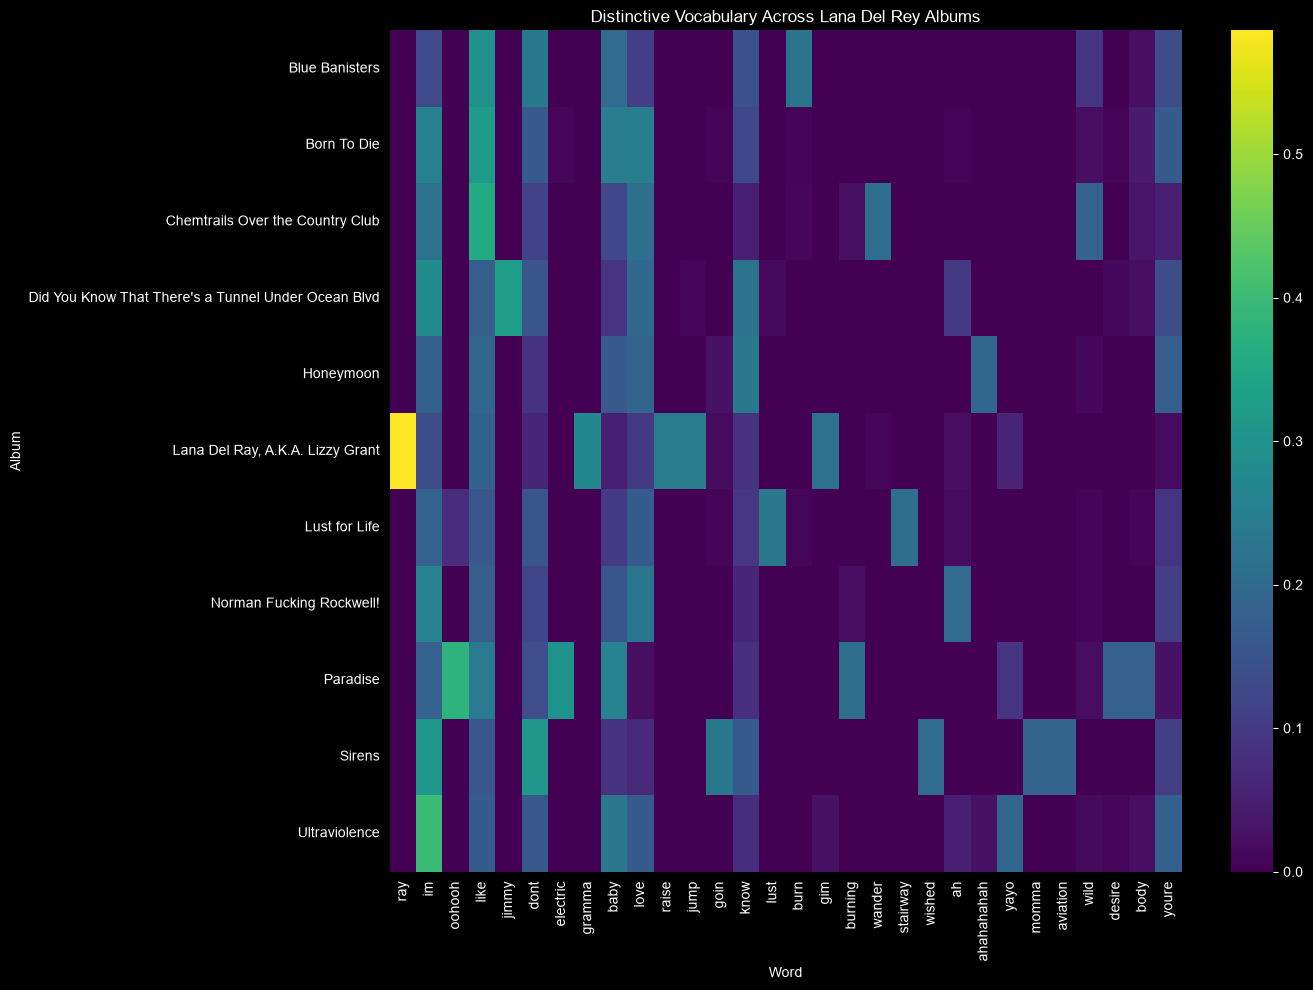

In [43]:
# Take most distinctive word and put them into a matrix
top_words = (
    tfidf_top_words_df
    .groupby("word")["tfidf"]
    .max()
    .sort_values(ascending=False)
    .head(30)
    .index
)

tfidf_heatmap = tfidf_df[top_words]

plt.figure(figsize=(14, 10))

sns.heatmap(
    tfidf_heatmap,
    annot=False,
    cmap="viridis"
)

plt.xlabel("Word")
plt.ylabel("Album")
plt.title("Distinctive Vocabulary Across Lana Del Rey Albums")
plt.tight_layout()
plt.show()


In [44]:
all_words = [
    word
    for song in df["nlp_cleaned_lyrics"]
    for word in song
]

Counter(all_words).most_common(50)

[('im', 593),
 ('like', 551),
 ('love', 407),
 ('baby', 390),
 ('dont', 383),
 ('know', 316),
 ('youre', 283),
 ('na', 269),
 ('got', 231),
 ('get', 223),
 ('cause', 192),
 ('wan', 172),
 ('say', 167),
 ('yeah', 162),
 ('take', 161),
 ('oh', 157),
 ('go', 145),
 ('come', 143),
 ('let', 140),
 ('one', 136),
 ('make', 133),
 ('want', 129),
 ('time', 127),
 ('life', 127),
 ('god', 124),
 ('blue', 124),
 ('light', 123),
 ('feel', 117),
 ('think', 107),
 ('never', 107),
 ('man', 106),
 ('back', 104),
 ('girl', 104),
 ('way', 102),
 ('there', 100),
 ('ill', 98),
 ('ooh', 96),
 ('said', 94),
 ('thing', 93),
 ('put', 92),
 ('thats', 87),
 ('could', 87),
 ('crazy', 85),
 ('tell', 85),
 ('gon', 82),
 ('keep', 82),
 ('high', 82),
 ('ive', 78),
 ('see', 77),
 ('white', 75)]